In [7]:
from dataclasses import dataclass
from typing import Any, Dict, Optional, Tuple
import numpy as np
from scipy.optimize import root
from scipy.sparse import csr_matrix, diags, eye
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

In [8]:
# ============================================================
#  Parameters for Gaussian iid multi-area network
# ============================================================

@dataclass(frozen=True)
class GaussianAreaParams:
    """
    N   : number of neurons in this area
    mu  : mean of LOCAL recurrent weights inside this area
    var : unscaled variance parameter of LOCAL block
          actual sampling variance used in code is var / N_area
    """
    N: int
    mu: float
    var: float


@dataclass(frozen=True)
class GaussianMultiAreaParams:
    """
    mu_cross[src, tgt]  : mean of cross-area weights from src -> tgt
    var_cross[src, tgt] : unscaled variance parameter of cross-area block
                          actual sampling variance used in code is
                              var_cross[src, tgt] / N_tgt
    """
    areas: Tuple[GaussianAreaParams, ...]
    mu_cross: np.ndarray
    var_cross: np.ndarray
    activation: str
    phi_max: float
    gamma: float
    dt: float
    T: float
    seed: int = 0


# ============================================================
#  Activation function
# ============================================================

def phi(x: np.ndarray, p: GaussianMultiAreaParams) -> np.ndarray:
    """
    Same activation convention as your current code.
    """
    if p.activation == "tanh":
        return np.tanh(x) + 1.0

    if p.activation == "threshold_linear":
        y = np.maximum(0.0, x + p.gamma)
        if np.isfinite(p.phi_max):
            y = np.minimum(y, p.phi_max)
        return y

    raise ValueError(f"Unknown activation = {p.activation}")


def phi_prime(x: np.ndarray, p: GaussianMultiAreaParams) -> np.ndarray:
    """
    Derivative of activation function.
    """
    x = np.asarray(x, dtype=float)

    if p.activation == "tanh":
        y = np.tanh(x)
        return 1.0 - y * y

    if p.activation == "threshold_linear":
        g = ((x + p.gamma) >= 0.0).astype(float)
        if np.isfinite(p.phi_max):
            g = g * ((x + p.gamma) < p.phi_max)
        return g

    raise ValueError(f"Unknown activation = {p.activation}")


# ============================================================
#  Bookkeeping
# ============================================================

def area_info_gaussian(p: GaussianMultiAreaParams) -> Dict[str, Any]:
    """
    Build area slices for the full multi-area matrix.

    Returns:
    - N_total
    - area_slices[area_id] = slice of that area in the full network
    - area_sizes
    """
    area_slices = {}
    area_sizes = []
    start = 0

    for area_id, ap in enumerate(p.areas):
        if ap.N <= 0:
            raise ValueError(f"Area {area_id}: N must be positive")
        if ap.var < 0.0:
            raise ValueError(f"Area {area_id}: var must be non-negative")

        area_slices[area_id] = slice(start, start + ap.N)
        area_sizes.append(ap.N)
        start += ap.N

    return {
        "N_total": start,
        "area_slices": area_slices,
        "area_sizes": np.asarray(area_sizes, dtype=int),
    }


def _validate_gaussian_params(p: GaussianMultiAreaParams) -> None:
    """
    Basic parameter validation.
    """
    A = len(p.areas)

    if p.mu_cross.shape != (A, A):
        raise ValueError(f"mu_cross must have shape ({A}, {A})")

    if p.var_cross.shape != (A, A):
        raise ValueError(f"var_cross must have shape ({A}, {A})")

    if np.any(p.var_cross < 0.0):
        raise ValueError("All entries in var_cross must be non-negative")


# ============================================================
#  Build dense Gaussian iid multi-area connectivity
# ============================================================

def build_multi_area_gaussian_connectivity(
    p: GaussianMultiAreaParams,
) -> Tuple[np.ndarray, Dict[str, Any]]:
    """
    Build the full dense multi-area connectivity matrix W.

    Convention:
    - W[i, j] means neuron j projects to neuron i
    - so each block is placed as:
          W[target_slice, source_slice]

    Sampling rule:
    1) local block of area k:
         W[area_k, area_k] ~ iid Normal(mu_k, var_k / N_k)

    2) cross block from src -> tgt:
         W[tgt_slice, src_slice] ~ iid Normal(mu_cross[src, tgt],
                                             var_cross[src, tgt] / N_tgt)

    Important:
    - scale variance with 1/N
    - no scale of mean, directly use mu
    """
    _validate_gaussian_params(p)
    rng = np.random.default_rng(p.seed)

    info = area_info_gaussian(p)
    A = len(p.areas)
    N_total = info["N_total"]
    area_slices = info["area_slices"]

    W = np.zeros((N_total, N_total), dtype=float)

    for tgt in range(A):
        tgt_sl = area_slices[tgt]
        N_tgt = p.areas[tgt].N

        for src in range(A):
            src_sl = area_slices[src]
            N_src = p.areas[src].N

            if src == tgt:
                # ---------- local block ----------
                mu = p.areas[src].mu
                var_input = p.areas[src].var
                var_eff = var_input / N_tgt  

            else:
                # ---------- cross-area block: src -> tgt ----------
                mu = float(p.mu_cross[src, tgt])
                var_input = float(p.var_cross[src, tgt])
                var_eff = var_input / N_src

            block = rng.normal(
                loc=mu,
                scale=np.sqrt(var_eff),
                size=(N_tgt, N_src),
            )

            W[tgt_sl, src_sl] = block

    meta = {
        "N_total": N_total,
        "area_slices": area_slices,
        "area_sizes": info["area_sizes"],
    }
    return W, meta

# ============================================================
#  Full-network fixed point solver
#  Solve directly:
#       x* = W @ phi(x*)
# ============================================================

def solve_full_fixed_point(
    W: np.ndarray,
    p: GaussianMultiAreaParams,
    x0_init: Optional[np.ndarray] = None,
    damp: float = 0.3,
    tol: float = 1e-5,
    max_iter: int = 5000,
    verbose: bool = False,
) -> np.ndarray:
    """
    Solve full neuron-level fixed point directly:
        x* = W @ phi(x*)

    by damped fixed-point iteration.
    """
    N = W.shape[0]

    if x0_init is None:
        x = np.zeros(N, dtype=float)
    else:
        x = np.asarray(x0_init, dtype=float).copy()
        if x.shape != (N,):
            raise ValueError(f"x0_init must have shape ({N},)")

    for k in range(max_iter):
        Tx = W @ phi(x, p)
        x_new = (1.0 - damp) * x + damp * Tx

        step_err = np.max(np.abs(x_new - x))
        residual = np.max(np.abs(-x_new + W @ phi(x_new, p)))

        if verbose and (k % 100 == 0 or k < 10):
            print(f"[iter {k:4d}] step_err = {step_err:.3e}, residual = {residual:.3e}")

        if step_err < tol and residual < tol:
            if verbose:
                print(f"Converged at iter {k}: step_err={step_err:.3e}, residual={residual:.3e}")
            return x_new

        x = x_new

    raise RuntimeError(
        f"Full fixed point solver did not converge within max_iter={max_iter}. "
        f"Last step_err={step_err:.3e}, residual={residual:.3e}"
    )


# ============================================================
#  Full stability matrix
# ============================================================

def build_full_stability_matrix(
    W: np.ndarray,
    p: GaussianMultiAreaParams,
    x_star: np.ndarray,
) -> np.ndarray:
    """
    Full Jacobian:
        A = -I + W @ diag(phi'(x_star))

    Here we do NOT explicitly build diag(...).
    Since right-multiplying by a diagonal matrix is just
    scaling each column j by gain[j], we write:

        W @ diag(gain)  ==  W * gain[None, :]
    """
    N = W.shape[0]
    x_star = np.asarray(x_star, dtype=float)

    if x_star.shape != (N,):
        raise ValueError(f"x_star must have shape ({N},)")

    gain = phi_prime(x_star, p)
    A = -np.eye(N) + W * gain[None, :]
    return A


# ============================================================
#  Spectra
# ============================================================

def compute_connectivity_spectrum(W: np.ndarray) -> np.ndarray:
    """
    Spectrum of the full connectivity matrix W.
    """
    return np.linalg.eigvals(W)


def compute_linearized_operator_spectrum(
    W: np.ndarray,
    p: GaussianMultiAreaParams,
    x_star: np.ndarray,
) -> np.ndarray:
    """
    Spectrum of:
        M = W @ diag(phi'(x_star))
    """
    gain = phi_prime(x_star, p)
    M = W * gain[None, :]
    return np.linalg.eigvals(M)


def compute_stability_spectrum(
    W: np.ndarray,
    p: GaussianMultiAreaParams,
    x_star: np.ndarray,
) -> np.ndarray:
    """
    Spectrum of the full Jacobian:
        A = -I + W @ diag(phi'(x_star))
    """
    A = build_full_stability_matrix(W, p, x_star)
    return np.linalg.eigvals(A)

In [9]:
from typing import Optional, Dict, Any
import numpy as np


# ============================================================
#  Simulation by area for Gaussian multi-area network
# ============================================================

def simulate_rate_network_by_area_gaussian(
    W: np.ndarray,
    p: GaussianMultiAreaParams,
    n_trace_per_area: int = 10,
    x_init: Optional[np.ndarray] = None,
    trace_seed: int = 0,
    stop_if_abs_rate_exceeds: Optional[float] = None,
):
    """
    Simulate:
        dx/dt = -x + W @ phi(x)

    sample each area

    Returns
    -------
    t : array, shape (n_steps+1,)
    traces_by_area : dict[area_id] -> array, shape (n_steps+1, n_trace_this_area)
    x_final : final state
    trace_idx_by_area : dict[area_id] -> sampled neuron indices
    """
    rng = np.random.default_rng(trace_seed)
    N = W.shape[0]
    n_steps = int(round(p.T / p.dt))

    if x_init is None:
        x = 1e-2 * rng.standard_normal(N)
    else:
        x = np.asarray(x_init, dtype=float).copy()
        if x.shape != (N,):
            raise ValueError(f"x_init must have shape ({N},)")

    info = area_info_gaussian(p)
    area_slices = info["area_slices"]
    A = len(p.areas)

    trace_idx_by_area = {}
    traces_by_area = {}

    # random sampling for each area
    for area_id in range(A):
        sl = area_slices[area_id]
        area_idx = np.arange(sl.start, sl.stop)
        n_pick = min(n_trace_per_area, len(area_idx))

        picked = rng.choice(area_idx, size=n_pick, replace=False)
        trace_idx_by_area[area_id] = picked

        traces_by_area[area_id] = np.empty((n_steps + 1, n_pick), dtype=float)
        traces_by_area[area_id][0] = phi(x[picked], p)

    t = np.linspace(0.0, p.T, n_steps + 1)

    for k in range(1, n_steps + 1):
        r = phi(x, p)
        x = x + p.dt * (-x + W @ r)

        for area_id in range(A):
            picked = trace_idx_by_area[area_id]
            traces_by_area[area_id][k] = phi(x[picked], p)

        if stop_if_abs_rate_exceeds is not None:
            current_max = max(
                np.max(np.abs(traces_by_area[area_id][k]))
                for area_id in range(A)
            )
            if current_max > stop_if_abs_rate_exceeds:
                t = t[:k + 1]
                for area_id in range(A):
                    traces_by_area[area_id] = traces_by_area[area_id][:k + 1]
                break

    return t, traces_by_area, x, trace_idx_by_area

In [10]:
# ============================================================
#  Fig-like plot for Gaussian network, separated by area
# ============================================================

def plot_multi_area_fig_full_separate_areas_gaussian(
    W_base: np.ndarray,
    p: GaussianMultiAreaParams,
    alphas,
    n_trace_per_area: int = 10,
    trace_seed: int = 0,
    stop_if_abs_rate_exceeds: Optional[float] = None,
    spectrum_mode: str = "stability",   # "connectivity", "linearized", "stability"
    max_cols: int = 3,
    col_width: float = 4.2,
    row_height: float = 3.2,
):
    
    alphas = list(alphas)
    n = len(alphas)
    A = len(p.areas)

    ncols = min(max_cols, n)
    nrows = int(np.ceil(n / ncols))

    # vary by a global intensity scaling alpha, could ignore
    results = []
    x_star_prev = None

    for alpha in alphas:
        W_eff = alpha * W_base

        # ---------- simulate once ----------
        t, traces_by_area, x_final, trace_idx_by_area = simulate_rate_network_by_area_gaussian(
            W=W_eff,
            p=p,
            n_trace_per_area=n_trace_per_area,
            x_init=None,
            trace_seed=trace_seed,
            stop_if_abs_rate_exceeds=stop_if_abs_rate_exceeds,
        )

        # ---------- spectrum once ----------
        if spectrum_mode == "connectivity":
            eigvals = compute_connectivity_spectrum(W_eff)
            stability_re_line = 1.0

        else:
            x_star = solve_full_fixed_point(
                W=W_eff,
                p=p,
                x0_init=x_star_prev,
                damp=0.3,
                tol=1e-5,
                max_iter=5000,
                verbose=False,
            )
            x_star_prev = x_star.copy()

            if spectrum_mode == "linearized":
                eigvals = compute_linearized_operator_spectrum(
                    W=W_eff,
                    p=p,
                    x_star=x_star,
                )
                stability_re_line = 1.0

            elif spectrum_mode == "stability":
                eigvals = compute_stability_spectrum(
                    W=W_eff,
                    p=p,
                    x_star=x_star,
                )
                stability_re_line = 0.0

            else:
                raise ValueError("spectrum_mode must be 'connectivity', 'linearized', or 'stability'")

        results.append({
            "alpha": alpha,
            "t": t,
            "traces_by_area": traces_by_area,
            "eigvals": eigvals,
            "stability_re_line": stability_re_line,
        })

    figs = {}

    for area_id in range(A):
        fig, axes = plt.subplots(
            nrows, ncols,
            figsize=(col_width * ncols, row_height * nrows),
            constrained_layout=True
        )
        axes = np.atleast_1d(axes).ravel()

        for i, res in enumerate(results):
            ax = axes[i]

            t = res["t"]
            traces = res["traces_by_area"][area_id]
            eigvals = res["eigvals"]
            stability_re_line = res["stability_re_line"]
            alpha = res["alpha"]

            ax.plot(t, traces, linewidth=1.2)
            ax.grid(alpha=0.25)
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)

            if i % ncols == 0:
                ax.set_ylabel(r"Firing rate $\phi(x_i)$")
            else:
                ax.set_ylabel("")

            if i // ncols == nrows - 1:
                ax.set_xlabel("t")
            else:
                ax.set_xlabel("")

            ax.set_title(f"Area {area_id}", fontsize=11)
            '''
            iax = inset_axes(ax, width="33%", height="55%", loc="upper left", borderpad=1.0)
            iax.scatter(eigvals.real, eigvals.imag, s=2, alpha=0.25)
            iax.axvline(stability_re_line, color="red", linestyle="--", linewidth=1.0)
            iax.axhline(0.0, color="k", linewidth=0.5, alpha=0.35)
            iax.axvline(0.0, color="k", linewidth=0.5, alpha=0.35)
            iax.set_xticks([])
            iax.set_yticks([])
            iax.set_aspect("equal", "box")
            '''
        for j in range(n, nrows * ncols):
            axes[j].axis("off")

        figs[area_id] = fig

    return figs

Gaussian multi-area network meta:
N_total = 12000
Density = 1.0
Area sizes = [4000 8000]

Full fixed point solved.
max Re(lambda_connectivity) = 1.046542940051523


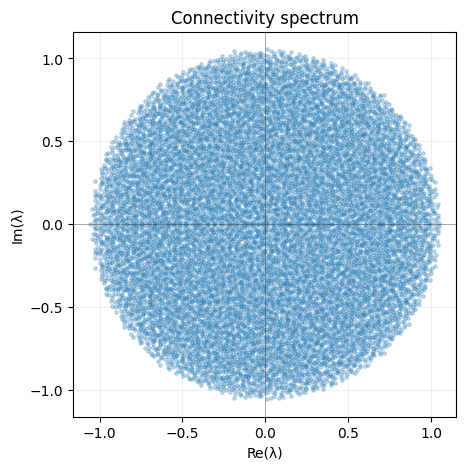

max Re(lambda_linearized) = 0.863787914582303


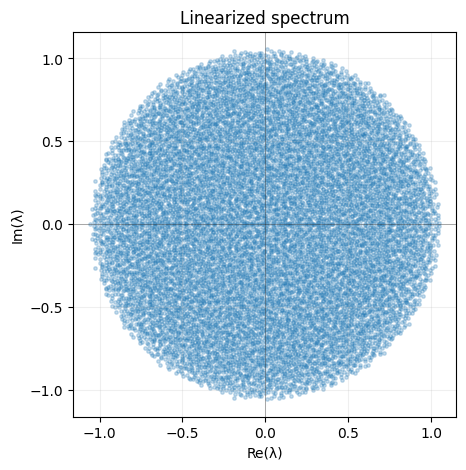

max Re(lambda_stability) = -0.13621208541772326


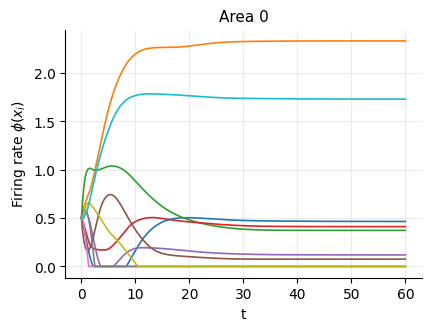

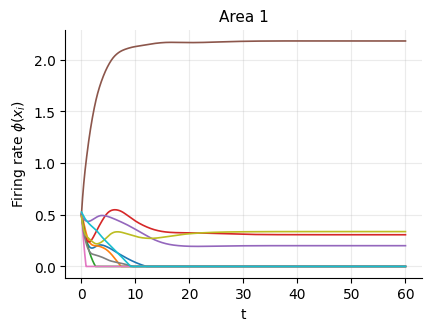

In [13]:
def main():
    # ========================================================
    # 1) Define each area: N, local mean, local variance parameter
    # ========================================================
    areas = (
        GaussianAreaParams(
            N=4000,
            mu=0.0,
            var=1.0,
        ),
        GaussianAreaParams(
            N=8000,
            mu=0.0,
            var=0.8,
        ),
    )

    A = len(areas)

    # ========================================================
    # 2) Define cross-area means and variance parameters
    #    mu_cross[src, tgt], var_cross[src, tgt]
    # ========================================================
    mu_cross = np.zeros((A, A))
    var_cross = np.zeros((A, A))

    # area 0 -> area 1
    mu_cross[0, 1] = 0.0
    var_cross[0, 1] = 0.1

    # area 1 -> area 0
    mu_cross[1, 0] = 0.0
    var_cross[1, 0] = 0.3

    # ========================================================
    # 3) Pack parameters
    # ========================================================
    p = GaussianMultiAreaParams(
        areas=areas,
        mu_cross=mu_cross,
        var_cross=var_cross,
        activation="threshold_linear",
        phi_max=np.inf,
        gamma=0.5,
        dt=0.005,
        T=60.0,
        seed=0,
    )

    # ========================================================
    # 4) Build Gaussian iid multi-area connectivity
    # ========================================================
    W_base, meta = build_multi_area_gaussian_connectivity(p)

    print("Gaussian multi-area network meta:")
    print("N_total =", meta["N_total"])
    print("Area sizes =", meta["area_sizes"])

    # ========================================================
    # 5) Solve full fixed point and stability spectrum at alpha0
    # ========================================================
    alpha0 = 1.0
    W_eff = alpha0 * W_base

    x_star = solve_full_fixed_point(
        W=W_eff,
        p=p,
        x0_init=None,
        damp=0.3,
        tol=1e-5,
        max_iter=5000,
        verbose=False,
    )

    print("\nFull fixed point solved.")

    eig_W = compute_connectivity_spectrum(W_eff)
    print("max Re(lambda_connectivity) =", np.max(eig_W.real))
    plt.figure(figsize=(5, 5))
    plt.scatter(eig_W.real, eig_W.imag, s=6, alpha=0.25)
    plt.axvline(0.0, color="k", linewidth=0.6, alpha=0.35)
    plt.axhline(0.0, color="k", linewidth=0.6, alpha=0.35)
    plt.title(f"Connectivity spectrum")
    plt.xlabel("Re(λ)")
    plt.ylabel("Im(λ)")
    plt.gca().set_aspect("equal", "box")
    plt.grid(alpha=0.2)
    plt.show()

    eig_L = compute_linearized_operator_spectrum(W_eff, p, x_star)
    print("max Re(lambda_linearized) =", np.max(eig_L.real))
    plt.figure(figsize=(5, 5))
    plt.scatter(eig_L.real, eig_L.imag, s=6, alpha=0.25)
    plt.axvline(0.0, color="k", linewidth=0.6, alpha=0.35)
    plt.axhline(0.0, color="k", linewidth=0.6, alpha=0.35)
    plt.title(f"Linearized spectrum")
    plt.xlabel("Re(λ)")
    plt.ylabel("Im(λ)")
    plt.gca().set_aspect("equal", "box")
    plt.grid(alpha=0.2)
    plt.show()

    eig_jac = compute_stability_spectrum(
        W=W_eff,
        p=p,
        x_star=x_star,
        )
    print("max Re(lambda_stability) =", np.max(eig_jac.real))

    # ========================================================
    # 6) Plot dynamics separately for each area
    # ========================================================
    alphas = [1.0]

    figs = plot_multi_area_fig_full_separate_areas_gaussian(
        W_base=W_base,
        p=p,
        alphas=alphas,
        n_trace_per_area=10,
        trace_seed=0,
        stop_if_abs_rate_exceeds=500.0,
        spectrum_mode="linearized",   # "connectivity", "linearized", "stability"
    )

    for area_id, fig in figs.items():
        #fig.suptitle(f"Dynamics of sampled neurons from Area {area_id}", fontsize=14)
        plt.show()


if __name__ == "__main__":
    main()